Q1:You are given a large NumPy array of size 5000000 ini alized with random
values. Compute the following element-wise opera on: f(x)=x2+3x+5, for
each element in the array and convert it into a CUDA kernel using Numba.
Compare performance difference of CPU with GPU.
a. Modify the kernel to use float32 and float64

In [6]:
from numba import cuda
import time
import numpy as np
#cpu
N = 5_000_000
x1 = np.random.rand(N)

# CPU computation
start = time.time()
y_cpu = x1**2 + 3*x1 + 5
end = time.time()

print("CPU Time:", end - start)
#gpu kernel
from numba import cuda
import numpy as np
import time

# CUDA kernel
@cuda.jit
def compute_kernel(x, y):
    i = cuda.grid(1)
    if i < x.size:
        y[i] = x[i]**2 + 3*x[i] + 5

N = 5_000_000
x = np.random.rand(N)
y_gpu = np.zeros_like(x)

d_x = cuda.to_device(x)
d_y = cuda.device_array_like(x)

threads_per_block = 256
blocks_per_grid = (N + threads_per_block - 1) // threads_per_block

start = time.time()
compute_kernel[blocks_per_grid, threads_per_block](d_x, d_y)
cuda.synchronize()
end = time.time()

y_gpu = d_y.copy_to_host()

print("GPU Time:", end - start)


#fp32
x32 = np.random.rand(N).astype(np.float32)
y32 = np.zeros_like(x32)

@cuda.jit
def kernel_float32(x, y):
    i = cuda.grid(1)
    if i < x.size:
        y[i] = x[i]*x[i] + 3.0*x[i] + 5.0

#fp64
x64 = np.random.rand(N).astype(np.float64)
y64 = np.zeros_like(x64)

@cuda.jit
def kernel_float64(x, y):
    i = cuda.grid(1)
    if i < x.size:
        y[i] = x[i]*x[i] + 3.0*x[i] + 5.0

#computation times
start = time.time()
kernel_float32[blocks_per_grid, threads_per_block](d_x, d_y)
cuda.synchronize()
end = time.time()
print("GPU Time (float32):", end - start)

start = time.time()
kernel_float64[blocks_per_grid, threads_per_block](d_x, d_y)
cuda.synchronize()
end = time.time()
print("GPU Time (float64):", end - start)


CPU Time: 0.03470945358276367
GPU Time: 0.07021284103393555
GPU Time (float32): 0.06139779090881348
GPU Time (float64): 0.060019493103027344


Q2: Implement and benchmark a 1-D histogram computa on for 1 million
random values in Python using Numba. Compare different approaches (pure
Python, NumPy, and Numba-accelerated) and analyze performance and
correctness.

228 ms ± 6.01 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
14.6 ms ± 2.23 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


3.73 ms ± 603 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


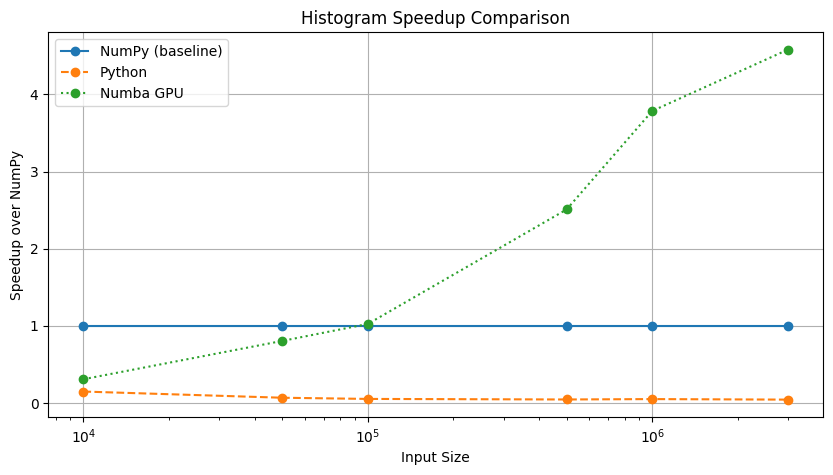

In [13]:
import numpy as np

N = 1_000_000
data = np.random.rand(N)
bins = 100
sizes = [10_000, 50_000, 100_000, 500_000, 1_000_000, 3_000_000]

#Pure Python
def histogram_python(data, bins):
    hist = [0]*bins
    for x in data:
        idx = int(x * bins)
        if idx == bins:
            idx -= 1
        hist[idx] += 1
    return hist


#Numpy
def numpy_histogram(a, bins):
    return np.histogram(a, bins)

#numba-accelerated
import numpy as np

import numba
from numba import cuda

@numba.jit(nopython=True)
def compute_bin(x, n, xmin, xmax):
    if x == xmax:
        return n - 1
    bin = np.int32(n * (np.float64(x) - np.float64(xmin)) / (np.float64(xmax) - np.float64(xmin)))

    if bin < 0 or bin >= n:
        return None
    else:
        return bin

@cuda.jit
def histogram(x, xmin, xmax, histogram_out):
    nbins = histogram_out.shape[0]
    bin_width = (xmax - xmin) / nbins

    start = cuda.grid(1)
    stride = cuda.gridsize(1)

    for i in range(start, x.shape[0], stride):
        bin_number = compute_bin(x[i], nbins, xmin, xmax)

        if bin_number >= 0 and bin_number < histogram_out.shape[0]:
            cuda.atomic.add(histogram_out, bin_number, 1)

@cuda.jit
def min_max(x, min_max_array):
    nelements = x.shape[0]

    start = cuda.grid(1)
    stride = cuda.gridsize(1)

    local_min = min_max_array[0]
    local_max = min_max_array[1]

    for i in range(start, x.shape[0], stride):
        element = x[i]
        local_min = min(element, local_min)
        local_max = max(element, local_max)

    cuda.atomic.min(min_max_array, 0, local_min)
    cuda.atomic.max(min_max_array, 1, local_max)


def dtype_min_max(dtype):
    '''Get the min and max value for a numeric dtype'''
    if np.issubdtype(dtype, np.integer):
        info = np.iinfo(dtype)
    else:
        info = np.finfo(dtype)
    return info.min, info.max


@numba.jit(nopython=True)
def get_bin_edges(a, nbins, a_min, a_max):
    bin_edges = np.empty((nbins+1,), dtype=np.float64)
    delta = (a_max - a_min) / nbins
    for i in range(bin_edges.shape[0]):
        bin_edges[i] = a_min + i * delta

    bin_edges[-1] = a_max
    return bin_edges


def numba_gpu_histogram(a, bins):
    a_gpu = cuda.to_device(a)

    dtype_min, dtype_max = dtype_min_max(a.dtype)
    min_max_array_gpu = cuda.to_device(np.array([dtype_max, dtype_min], dtype=a.dtype))
    min_max[64, 64](a_gpu, min_max_array_gpu)
    a_min, a_max = min_max_array_gpu.copy_to_host()

    bin_edges = get_bin_edges(a, bins, a_min, a_max)

    histogram_out = cuda.to_device(np.zeros(shape=(bins,), dtype=np.int32))
    histogram[64, 64](a_gpu, a_min, a_max, histogram_out)

    return histogram_out.copy_to_host(), bin_edges

#comparison
%timeit histogram_python(data, bins)
%timeit numpy_histogram(data, bins)
%timeit numba_gpu_histogram(data, bins)

#plot comparison
import time

speedup_python = []
speedup_numba_gpu = []
speedup_numpy = []

#warmup

numba_gpu_histogram(np.random.rand(1000).astype(np.float32), bins)
for N in sizes:
    data = np.random.rand(N).astype(np.float32)

    start = time.time()
    numpy_histogram(data, bins)
    numpy_time = time.time() - start

    start = time.time()
    histogram_python(data, bins)
    python_time = time.time() - start

    start = time.time()
    numba_gpu_histogram(data, bins)
    gpu_time = time.time() - start

    speedup_python.append(numpy_time / python_time)
    speedup_numba_gpu.append(numpy_time / gpu_time)
    speedup_numpy.append(1)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(sizes, speedup_numpy, 'o-', label="NumPy (baseline)")
plt.plot(sizes, speedup_python, 'o--', label="Python")
plt.plot(sizes, speedup_numba_gpu, 'o:', label="Numba GPU")

plt.xscale('log')  # important (like reference)
plt.xlabel("Input Size")
plt.ylabel("Speedup over NumPy")
plt.title("Histogram Speedup Comparison")

plt.legend()
plt.grid(True)
plt.show()

Q3: Write a func on monte_carlo_pi(nsamples) that esmates the value of π by
genera ng random x, y coordinates between 0 and 1 and checking if they fall
inside a unit circle (x2 + y2 < 1).
a. Implement the func on in pure Python first and later create a Numba
version.  
b. Program a script to compare the execu on me for 5 million samples.
Report the Speedup Factor (Python Time / Numba Time).  
c. Why does the very first execu on of the Numba func on take slightly
longer than the second execution?

In [14]:
#pure python
import random
import time

def monte_carlo_pi_python(nsamples):
    inside = 0
    for _ in range(nsamples):
        x = random.random()
        y = random.random()
        if x*x + y*y < 1:
            inside += 1
    return 4 * inside / nsamples

#NUMBA
import numpy as np
from numba import njit

@njit
def monte_carlo_pi_numba(nsamples):
    inside = 0
    for i in range(nsamples):
        x = np.random.random()
        y = np.random.random()
        if x*x + y*y < 1:
            inside += 1
    return 4 * inside / nsamples

N = 5_000_000

start = time.time()
pi_python = monte_carlo_pi_python(N)
python_time = time.time() - start

#Numba first call
start = time.time()
pi_numba = monte_carlo_pi_numba(N)
numba_time1 = time.time() - start

# Numba second run
start = time.time()
pi_numba = monte_carlo_pi_numba(N)
numba_time2 = time.time() - start

speedup = python_time / numba_time2

print("Pi (Python):", pi_python)
print("Pi (Numba):", pi_numba)

print("Python Time:", python_time)
print("Numba Time (1st):", numba_time1)
print("Numba Time (2nd):", numba_time2)

print("Speedup Factor:", speedup)

#c)
'''The first execution of a Numba function takes longer because Numba performs Just-In-Time (JIT) compilation during the first call.
It translates Python code into optimized machine code.
Subsequent executions reuse the compiled version, resulting in significantly faster performance.
'''

Pi (Python): 3.1414656
Pi (Numba): 3.1426128
Python Time: 0.8631565570831299
Numba Time (1st): 0.17164826393127441
Numba Time (2nd): 0.05434417724609375
Speedup Factor: 15.883147023725957


Q4: You have a 1D NumPy array represen ng pixel intensi es (values 0–255). You
need to increase the brightness of every pixel by 20%, but ensure no value
exceeds 255.
a. Write a func on adjust_brightness(pixel_value) using the @vectorize
decorator.
b. Apply this func on to an array of 10 million random integers.
c. Change the decorator to @vectorize(['int64(int64)'], target='parallel').
Measure the me difference when the work is automa cally split
across your CPU cores.
d. What happens if you try to pass a list instead of a NumPy array to this
func on?

In [4]:
import numpy as np
from numba import vectorize
#a)
@vectorize(['int64(int64)'])
def adjust_brightness(pixel_value):
    val = int(pixel_value * 1.2)
    if val > 255:
        return 255
    return val

#b)
import time

pixels = np.random.randint(0, 256, size=10_000_000, dtype=np.int64)

start = time.time()
bright_pixels = adjust_brightness(pixels)
end = time.time()
normal_time = end - start
print("Time (Normal Vectorize):", normal_time)

#c)
from numba import vectorize

@vectorize(['int64(int64)'], target='parallel')
def adjust_brightness_parallel(pixel_value):
    val = int(pixel_value * 1.2)
    if val > 255:
        return 255
    return val

start = time.time()
bright_parallel = adjust_brightness_parallel(pixels)
end = time.time()

parallel_time = end - start
print("Time (Parallel):", parallel_time)
speedup = normal_time / parallel_time
print("Speedup:", speedup)
'''
When a Python list is passed instead of a NumPy array, Numba attempts to convert it into an array, which introduces overhead.
This reduces performance and may prevent full optimization. Therefore, NumPy arrays are preferred for efficient execution.
'''

Time (Normal Vectorize): 0.026085853576660156
Time (Parallel): 0.021659135818481445
Speedup: 1.2043810886675106


'\nWhen a Python list is passed instead of a NumPy array, Numba attempts to convert it into an array, which introduces overhead. \nThis reduces performance and may prevent full optimization. Therefore, NumPy arrays are preferred for efficient execution.\n'

Q5:Write Python code to generate synthe c training data of 100,000 samples,
10 features and binary labels {-1, +1}. Implement binary logis c regression
using the mathema cal formula for gradient descent:
a. Using standard NumPy (without Numba)
b. Using Numba JIT accelera on
c. Compare correctness and performance.

In [6]:
import numpy as np

np.random.seed(42)

N = 100_000
D = 10

X = np.random.randn(N, D)

true_w = np.random.randn(D)

y = np.sign(X @ true_w + 0.5*np.random.randn(N))
y[y == 0] = 1

#numpy
import time

def logistic_regression_numpy(X, y, lr=0.01, epochs=50):
    N, D = X.shape
    w = np.zeros(D)

    for _ in range(epochs):
        z = X @ w
        yz = y * z
        gradient = -(X.T @ (y / (1 + np.exp(yz)))) / N
        w -= lr * gradient

    return w

#numba-jit
from numba import njit

@njit
def logistic_regression_numba(X, y, lr, epochs):
    N, D = X.shape
    w = np.zeros(D)

    for _ in range(epochs):
        gradient = np.zeros(D)

        for i in range(N):
            dot = 0.0
            for j in range(D):
                dot += X[i, j] * w[j]

            yz = y[i] * dot
            coeff = -y[i] / (1.0 + np.exp(yz))

            for j in range(D):
                gradient[j] += coeff * X[i, j]

        for j in range(D):
            w[j] -= lr * gradient[j] / N

    return w

#comparison
# numpy time
start = time.time()
w_numpy = logistic_regression_numpy(X, y)
time_numpy = time.time() - start

# Numba first call
start = time.time()
w_numba = logistic_regression_numba(X, y, 0.01, 50)
time_numba1 = time.time() - start

# Numba second call
start = time.time()
w_numba = logistic_regression_numba(X, y, 0.01, 50)
time_numba2 = time.time() - start

print("NumPy Time:", time_numpy)
print("Numba Time (1st):", time_numba1)
print("Numba Time (2nd):", time_numba2)
print("Speedup:", time_numpy / time_numba2)

NumPy Time: 0.11681127548217773
Numba Time (1st): 0.417510986328125
Numba Time (2nd): 0.14154696464538574
Speedup: 0.8252474772229998


Q6:Write a CUDA kernel to add two large matrices (A + B = C) of size 1024 X 1024.

In [7]:
from numba import cuda
import numpy as np

@cuda.jit
def matrix_add(A, B, C):
    row, col = cuda.grid(2)

    if row < A.shape[0] and col < A.shape[1]:
        C[row, col] = A[row, col] + B[row, col]

N = 1024

A = np.random.rand(N, N).astype(np.float32)
B = np.random.rand(N, N).astype(np.float32)
C = np.zeros((N, N), dtype=np.float32)

d_A = cuda.to_device(A)
d_B = cuda.to_device(B)
d_C = cuda.device_array_like(A)

threads_per_block = (16, 16)

blocks_per_grid_x = (N + threads_per_block[0] - 1) // threads_per_block[0]
blocks_per_grid_y = (N + threads_per_block[1] - 1) // threads_per_block[1]

blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

matrix_add[blocks_per_grid, threads_per_block](d_A, d_B, d_C)

C = d_C.copy_to_host()

print(C)

[[0.6960686  1.3726364  1.0878179  ... 0.8752672  1.5528848  1.3005899 ]
 [1.3847768  0.77072436 1.0716691  ... 1.7498753  1.388656   0.13368383]
 [1.2039145  1.1422884  1.4722803  ... 0.7429076  0.6111526  0.46452853]
 ...
 [1.7638748  1.2417219  0.9079439  ... 0.36634216 1.3792449  1.8754573 ]
 [0.9549227  1.5527658  1.1647412  ... 0.42682654 0.9578527  1.0194585 ]
 [1.2125237  0.9841999  0.29369748 ... 0.19755667 0.82330084 0.51103854]]
